In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 

# Define default plotting parametersP
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

In [2]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('x1', 'Bridge width',        'motorized vehicle lanes'),
    ('x2', 'Vertical clearance',  'm'),
)

# set bounds for all variables
b1 = [2, 8]      # x1
b2 = [9.25, 14.5]      # x2
bounds = [b1, b2]

X_irl = [4, 11.4]
plot_irl = True  # Can be true or False, depending on whether you want to plot the IRL point or not

In [3]:
def constraint_1(variables):
    """no more than 8 lanes:

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    
    return x1 - 8 # < 0

def constraint_2(variables):
    """no more vertical clearance than 14.5 m.

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    
    return x2 - 14.5 # < 0     # Placeholder: no constraint, return zeros meaning no violation


#cons = [['ineq', constraint_1], ['ineq', constraint_2]]

def constraint_3(variables):
    """Constraint placeholder: return per-individual zeros (no violation).
    
    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    
    return np.zeros_like(x1) # < 0     # Placeholder: no constraint, return zeros meaning no violation

def constraint_4(variables):
    """Constraint placeholder: return per-individual zeros (no violation).

    :return: 1-D array (length n) with constraint values; arr>0 means violation for 'ineq' constraints.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]

    return np.zeros_like(x1) # < 0     # Placeholder: no constraint, return zeros meaning no violation


cons = [['ineq', constraint_3], ['ineq', constraint_4]]

In [9]:
# Define objective functions

def objective_function_1(x1, x2):
    """
    Cost function.
    
    :return: float of construction cost in euros.
    """
    cons1 = 72500000           # costs per lane
    cons2 = 34100000/1.35      # cost per metre vertical clearance

    
    #if x1 <= 4 and x2 <= 11.4:
    #    return 4*cons1 - cons1 * x1 + 11.4 * cons2 - cons2 * x2
    #elif x1 <= 4 and x2 > 11.4:
    #    return 4*cons1 - cons1 * x1 - 11.4 * cons2 + cons2 * x2
    #elif x1 > 4 and x2 <= 11.4:
    #    return -4*cons1 + cons1 * x1 + 11.4 * cons2 - cons2 * x2
    #elif x1 > 4 and x2 > 11.4:
    #    return -4*cons1 + cons1 * x1 - 11.4 * cons2 + cons2 * x2

    return cons1 * np.abs(x1 - 4) + cons2 * np.abs(x2 - 11.4)


def objective_function_2(x1, x2):
    """
    Water Pollution function.
    
    :return: float of water pollution in ships/hour.
    """
    x = np.array([9.25, 10.5, 11.5, 12.5, 13.5, 14.5])
    y = np.array([0.42, 0.5785, 0.62575, 0.649375, 0.661, 0.679])
    coefficienten = np.polyfit(x, y, 2)
    f = np.poly1d(coefficienten)

    return f(x2) * 15


def objective_function_3(x1, x2):
    """
    Shipping flow function.
    
    :return: float of shipping flow in ships/hour.
    """
    x = np.array([9.25, 10.5, 11.5, 12.5, 13.5, 14.5])
    y = np.array([0.42, 0.5785, 0.62575, 0.649375, 0.661, 0.679])
    coefficienten = np.polyfit(x, y, 2)
    f = np.poly1d(coefficienten)
    
    return f(x2) * 15


def objective_function_4(x1, x2):
    """
    Disturbance function.
    
    :return: float of disturbance in terms of expected number of complaints per year.
    """
    cons13 = 1/(24*800)     # complaints per vehicle
    cons14 = 4.8/78 * 1/(24*15)     # complaints per ship
    cons15 = 800     # vehicles/hour/4 lanes
    x = np.array([9.25, 10.5, 11.5, 12.5, 13.5, 14.5])
    y = np.array([0.42, 0.5785, 0.62575, 0.649375, 0.661, 0.679])
    coefficienten = np.polyfit(x, y, 2)
    f = np.poly1d(coefficienten)

    return (cons13 * x1/4 * cons15 + cons14 * f(x2) * 15)*24*365


def objective_function_5(x1, x2):
    """
    Traffic flow function.
    
    :return: float of predicted traffic flow in vehicles/hour.
    """
    cons16 = 800     # vehicles/hour/4 lanes
    return x1/4 * cons16


# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_function_1, "Cost",                   "€",                                "Municipality of Rotterdam"),
    (objective_function_2, "Water Pollution",        "ships/hour",                       "Rijkswaterstaat"),
    (objective_function_3, "Shipping flow",          "ships/hour",                       "Port of Rotterdam"),
    (objective_function_4, "Disturbance",            "complaints/year",                  "Inhabitants"),
    (objective_function_5, "Traffic flow",           "vehicles/hour",                    "Road users")
]


In [10]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {} # Dictionary to store the min and max values for each objective       
midpoints = [np.mean(b) for b in bounds]

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1: sign * obj_func(*x)  # obj_func accepts a single array-like X
    
    min_val =  minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x: wrapped(x, sign=-1), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")


  Objective 1  :    min =             0.4  €               max =   368,303,703.7  €
  Objective 2  :    min =             6.5  ships/hour      max =            10.2  ships/hour
  Objective 3  :    min =             6.5  ships/hour      max =            10.2  ships/hour
  Objective 4  :    min =           192.2  complaints/year    max =           745.2  complaints/year
  Objective 5  :    min =           400.0  vehicles/hour    max =         1,600.0  vehicles/hour


In [11]:
# Weights per stakeholder — must sum to 1. Before game all weights were set equal.
#                   cost   poll  ship  dist  traffic
weights_before =    [0.20, 0.20, 0.20, 0.20, 0.20]
weights_after =     [0.30, 0.15, 0.20, 0.20, 0.15]

weights = weights_before  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

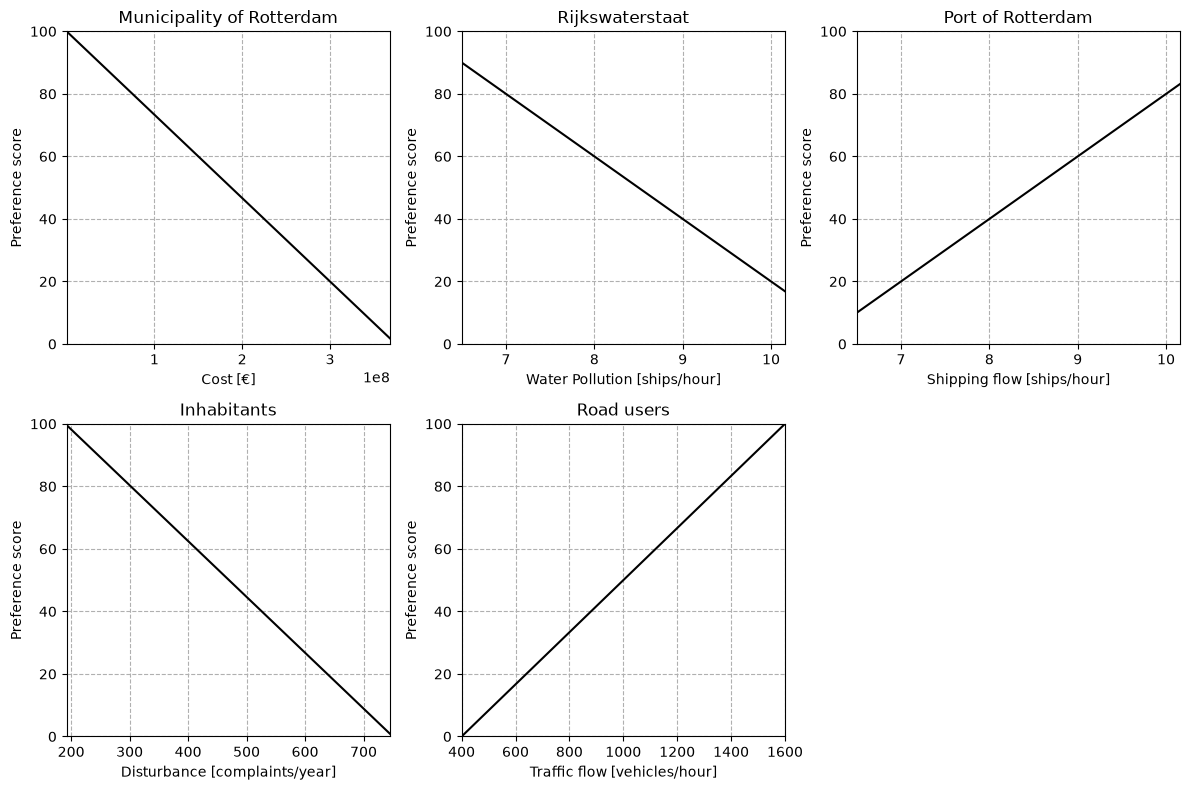

In [12]:
# Define preferences
prefs_before = [[[0, 375000000],                  [100, 0]],          # preference cost
                [[6, 11],                         [100, 0]],          # preference pollution
                [[6, 11],                         [0, 100]],          # preference ship flow
                [[190, 750],                      [100, 0]],          # preference complaints
                [[400, 1600],                     [0, 100]]]          # preference traffic flow

pref_after = [[[150000, 2000000, 4250000],      [100, 80, 0]],
                [[8, 120, 350],                 [0, 60, 100]],
                [[0, 80000, 150000, 375000],    [0, 100, 50, 0]],
                [[2, 9.5],                      [100, 0]],
                [[12500000, 250000000],                [0, 100]]]

prefs = prefs_before  # set to which preferences to use


# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

axes.flat[-1].set_visible(False)  # hide empty 6th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2):
    cost = objective_function_1(x1, x2)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2):
    pollution = objective_function_2(x1, x2)
    return pchip_interpolate(prefs[1][0], prefs[1][1], pollution)

def pref_func_3(x1, x2):
    ship_flow = objective_function_3(x1, x2)
    return pchip_interpolate(prefs[2][0], prefs[2][1], ship_flow)

def pref_func_4(x1, x2):
    disturbance = objective_function_4(x1, x2)
    return pchip_interpolate(prefs[3][0], prefs[3][1], disturbance)

def pref_func_5(x1, x2):
    traffic_flow = objective_function_5(x1, x2)
    return pchip_interpolate(prefs[4][0], prefs[4][1], traffic_flow)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4, pref_func_5]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2)
    p_2 = pref_func_2(x1, x2)
    p_3 = pref_func_3(x1, x2)
    p_4 = pref_func_4(x1, x2)
    p_5 = pref_func_5(x1, x2)
    
    return weights, [p_1, p_2, p_3, p_4, p_5]


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            10.5667      16.1904          0            0.008        0           
1            10.268       12.5889          0            0.168        0           
2            10.0176      11.0441          0            0.41         0           
3            10.0176      10.5523          1            0.403        0           
4            10.0176      10.6042          2            0.449        0           
5            10.0176      10.4899          3            0.456        0           
6            10.0176      10.5402          4            0.45         0           
7            10.0176      10.4672          5            0.453        0           
8            10.0176      10.5139          6            0.462        0           
9            10.0176      10.4075          7            0.458        0           
10           10.017

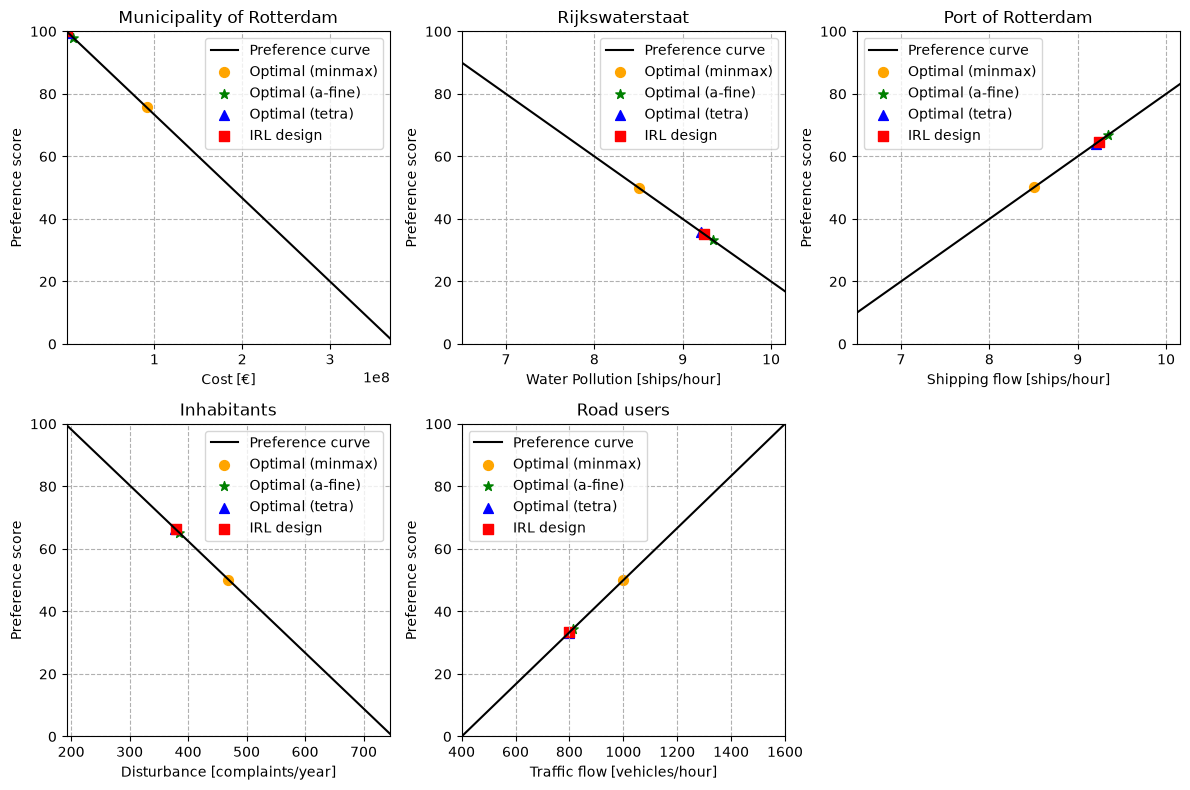

In [14]:
# We run the optimization with two paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*', '^']  # markers for the different paradigms
colours  = ['orange', 'green', 'blue']

# Define the figure and axes before the loop
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

start_points = [[4, 11.4]]

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run with the IMAP solver
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options, start_points_population=start_points)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var) # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var) # Calculate resulting preference score
    
        # Print and plot the optimal point on the preference curve
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:5]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:5]:
    ax.legend(fontsize=10)

axes.flat[-1].set_visible(False)  # hide the sixth empty subplot


# Adjust the layout 
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()